In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pathlib import Path
import warnings
from dotenv import load_dotenv

load_dotenv()

warnings.filterwarnings("ignore")

#start from current working directory
PROJECT_ROOT = Path.cwd()

#walk upward until locating the folder containing "data"
while not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

#processed data folder used for input/output
DATA_DIR = PROJECT_ROOT / "data" / "processed"

#input dataset produced from cleaning step
INPUT_PATH = DATA_DIR / "daily_sales_subcategory.csv"

#output forecast csv that streamlit will later load 
OUTPUT_PATH = DATA_DIR / "prophet_forecast_30_days_subcategory.csv"


print("Project root:", PROJECT_ROOT)
print("Input file:", INPUT_PATH)
print("Output file:", OUTPUT_PATH)
    

Project root: /Users/traceytrinitasidharta/Desktop/ForeSight
Input file: /Users/traceytrinitasidharta/Desktop/ForeSight/data/processed/daily_sales_subcategory.csv
Output file: /Users/traceytrinitasidharta/Desktop/ForeSight/data/processed/prophet_forecast_30_days_subcategory.csv


In [78]:
#forecast horizon
PERIODS = 30

#evaluation horizon
TEST_DAYS = 30

#minimum history required for subcategory modelling
MIN_POINTS = 60


df = pd.read_csv(INPUT_PATH)

#clean column headers (remove whitespace)
df.columns = df.columns.astype(str).str.strip()

#check that the required columns exist
required_cols = {"ds", "y", "category", "sub_category"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")
    
#convert ds to datetime and y to numeric
df["ds"] = pd.to_datetime(df["ds"], errors="coerce")
df["y"] = pd.to_numeric(df["y"], errors="coerce")

#standardize text columns (remove extra spacecs)
df["category"] = df["category"].astype(str).str.strip()
df["sub_category"] = df["sub_category"].astype(str).str.strip()

#remove rows that have missing key values and sort chronologically
df = df.dropna(subset=["ds", "y", "category", "sub_category"])
df = df.sort_values("ds")

#preview data and print summary info
display(df.head())
print("Rows:", len(df))
print("Date range:", df["ds"].min(), "→", df["ds"].max())

                                    
                                    

,ds,category,sub_category,y
0,2014-01-03,Office Supplies,Paper,16
1,2014-01-04,Office Supplies,Binders,4
2,2014-01-04,Office Supplies,Labels,12
3,2014-01-04,Office Supplies,Storage,273
4,2014-01-05,Office Supplies,Art,20


Rows: 6563
Date range: 2014-01-03 00:00:00 → 2017-12-30 00:00:00


In [96]:
#create prophet model with chosen seasonalities
def build_prophet_model() -> Prophet:
    return Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False
    )

#trains prophet model on (ds, y)
#will return forecast dataframe with ds, yhat, yhat_lower, yhat_upper
def train_and_forecast(series_df: pd.DataFrame, periods: int = 30):
    #prophet seasonalities 
    model = build_prophet_model()
    
    #fit prophet on historical data
    model.fit(series_df[["ds", "y"]])
    
    #create future dates for forecasting
    future = model.make_future_dataframe(periods = periods)
    
    #predicting value for history and future dates
    fc = model.predict(future)
    
    #keeping only columns needed for dashboard
    out = fc[["ds", "yhat", "yhat_lower", "yhat_upper"]].copy()
    
    #remove negative forecast result
    out["yhat"] = out["yhat"].clip(lower=0)
    out["yhat_lower"] = out["yhat_lower"].clip(lower=0)
    out["yhat_upper"] = out["yhat_upper"].clip(lower=0)
    
    return model, out

#evaluation 
def evaluate_prophet(series_df: pd.DataFrame, test_days: int = 30):
    series_df = series_df.sort_values("ds").copy()
    
    #evaluation on last test_days
    split_date = series_df["ds"].max() - pd.Timedelta(days=test_days)
    
    #training set up to split_date
    train_df = series_df[series_df["ds"] <= split_date].copy()
    
    #testing set after split_date
    test_df = series_df[series_df["ds"] > split_date].copy()
    
    mae = None
    rmse = None
    test_merge = pd.DataFrame()
    
    #training the model if both sets have data
    if len(train_df) > 0 and len(test_df) > 0:
        eval_model = build_prophet_model()
        eval_model.fit(train_df[["ds", "y"]])
        
        #forecast forward for the length of the test period
        future_eval = eval_model.make_future_dataframe(
            periods=len(test_df),
            include_history=False
        )
        fc_eval = eval_model.predict(future_eval)
        
        #merging predicted results with actual test data (ds)
        test_merge = test_df.merge(
            fc_eval[["ds", "yhat", "yhat_lower", "yhat_upper"]],
            on="ds",
            how="inner"
        )
        
        if not test_merge.empty:
            #remove negative predicted values
            test_merge["yhat"] = test_merge["yhat"].clip(lower=0)
            test_merge["yhat_lower"] = test_merge["yhat_lower"].clip(lower=0)
            test_merge["yhat_upper"] = test_merge["yhat_upper"].clip(lower=0)
            
            #evaluation metrics
            mae = mean_absolute_error(test_merge["y"], test_merge["yhat"])
            rmse = np.sqrt(mean_squared_error(test_merge["y"], test_merge["yhat"]))
        
    return mae, rmse, test_merge, train_df, test_df

In [89]:
#aggregate all categories and subcategories into one daily sales series
overall_df = (
    df.groupby("ds", as_index=False)["y"]
    .sum()
    .sort_values("ds")
)

print("\nOverall series rows:", len(overall_df))
print("Date range:", overall_df["ds"].min(), "→", overall_df["ds"].max())
display(overall_df.head())


Overall series rows: 1237
Date range: 2014-01-03 00:00:00 → 2017-12-30 00:00:00


,ds,y
0,2014-01-03,16
1,2014-01-04,289
2,2014-01-05,20
3,2014-01-06,4407
4,2014-01-07,87


In [90]:
#overall 30-day evaluation
mae, rmse, test_merge, train_df, test_df = evaluate_prophet(overall_df, test_days=TEST_DAYS)

#print to show test and train periods
print("\nTrain period:", train_df["ds"].min(), "→", train_df["ds"].max(), "| rows:", len(train_df))
print("Test period:", test_df["ds"].min(), "→", test_df["ds"].max(), "| rows:", len(test_df))

if mae is not None and rmse is not None:
    test_merge.to_csv(DATA_DIR / "prophet_test_merge.csv", index=False)
    
    print("\nEvaluation on last 30 days:")
    print("Mean Absolute Error (MAE):", round(mae, 2))
    print("Root Mean Squared Error (RMSE):", round(rmse, 2))
else:
    print("\nNot enough data for 30-day evaluation.")


13:02:41 - cmdstanpy - INFO - Chain [1] start processing
13:02:41 - cmdstanpy - INFO - Chain [1] done processing



Train period: 2014-01-03 00:00:00 → 2017-11-30 00:00:00 | rows: 1208
Test period: 2017-12-01 00:00:00 → 2017-12-30 00:00:00 | rows: 29

Evaluation on last 30 days:
Mean Absolute Error (MAE): 1916.8
Root Mean Squared Error (RMSE): 2341.41


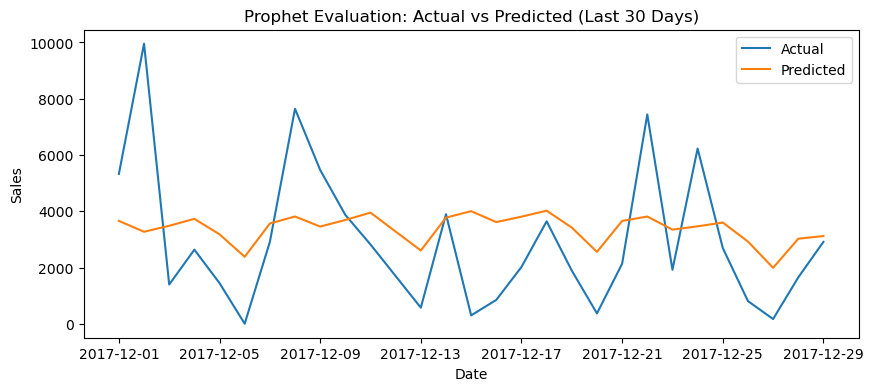

In [91]:
#plotting actual vs predicted on the test period
if not test_merge.empty:
    plt.figure(figsize=(10, 4))
    plt.plot(test_merge["ds"], test_merge["y"], label="Actual")
    plt.plot(test_merge["ds"], test_merge["yhat"], label="Predicted")
    plt.title("Prophet Evaluation: Actual vs Predicted (Last 30 Days)")
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.legend()
    plt.show()

13:02:50 - cmdstanpy - INFO - Chain [1] start processing
13:02:50 - cmdstanpy - INFO - Chain [1] done processing


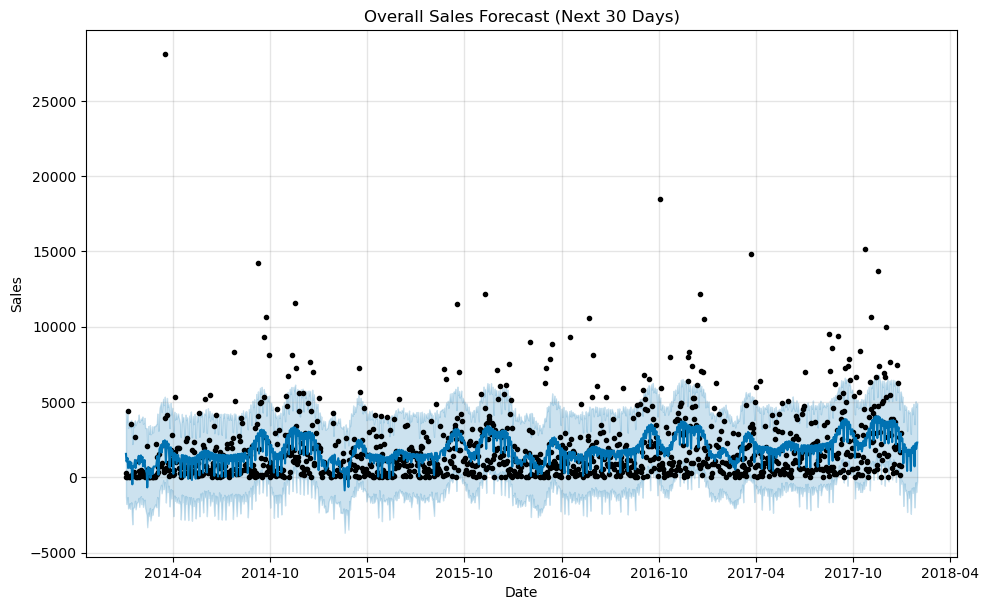

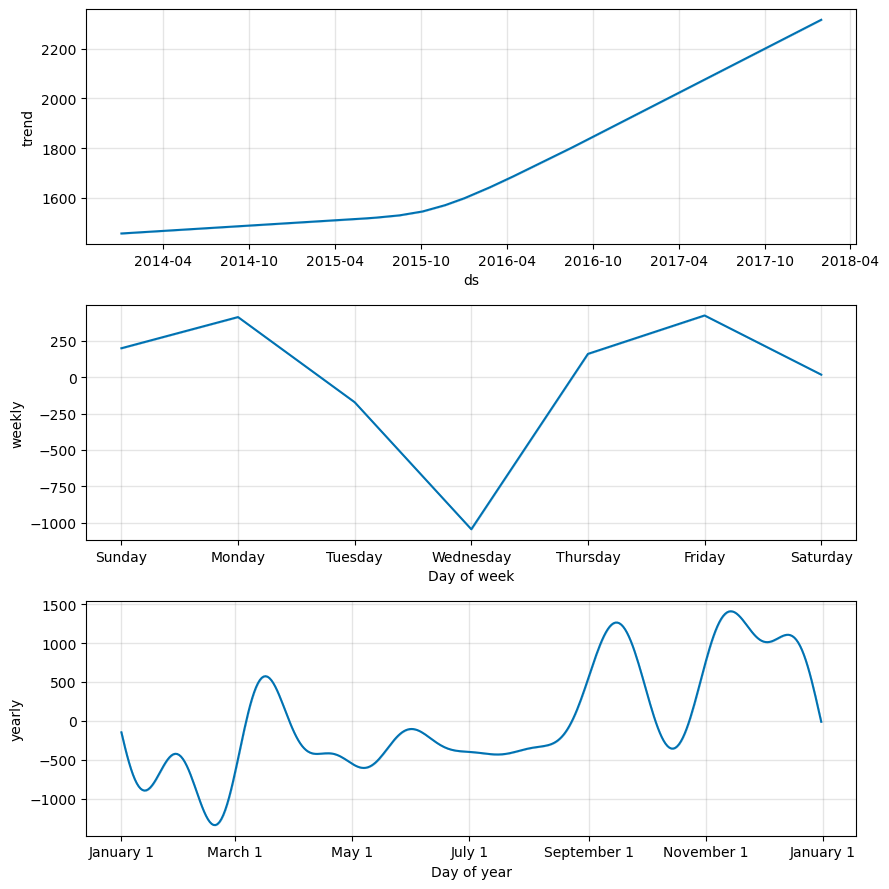

In [92]:
#train on all available data and forecast next 30 days
final_model, overall_forecast = train_and_forecast(overall_df[["ds", "y"]], periods=PERIODS)

#labelling the forecat as the overall series
overall_forecast["category"] = "All Sales"
overall_forecast["sub_category"] = "All Sub-Categories"

#keeping only future dates/predicted values
last_date_overall = overall_df["ds"].max()
overall_forecast = overall_forecast[overall_forecast["ds"] > last_date_overall].copy()

#plot overall forecast and its components
full_future = final_model.make_future_dataframe(periods=PERIODS)
fc = final_model.predict(full_future)

final_model.plot(fc)
plt.title("Overall Sales Forecast (Next 30 Days)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

final_model.plot_components(fc)
plt.show()

In [94]:
#store forecast outputs
all_rows = []

#store evaluation results
evaluation_rows = []

#get unique category and sub_category to forecast individually
pairs = (
    df[["category", "sub_category"]]
    .drop_duplicates()
    .sort_values(["category", "sub_category"])
)

print("\nForecasting pairs:", len(pairs))

#train a separate prophet model for category and sub_category
for _, row in pairs.iterrows():
    cat = row["category"]
    subcat = row["sub_category"]
    
    #build historical daily series
    hist = (
        df[(df["category"] == cat) & (df["sub_category"] ==subcat)]
        .groupby("ds", as_index=False)["y"]
        .sum()
        .sort_values("ds")
    )
    
    #skip series with too little data
    if len(hist) < MIN_POINTS: 
        print(f"Skipping {cat} - {subcat} (rows: {len(hist)})")
        continue
        
    
    #evaluate each subcategory on last 30 days
    mae_sub, rmse_sub, test_merge_subcat, train_hist, test_hist = evaluate_prophet(
        hist,
        test_days=TEST_DAYS
    )
    
    if mae_sub is not None and rmse_sub is not None:
        evaluation_rows.append({
            "category": cat,
            "sub_category": subcat,
            "mae": round(mae_sub, 2),
            "rmse": round(rmse_sub, 2)
        })
    
    #train and forecast subcategory
    model, fc_full = train_and_forecast(hist[["ds", "y"]], periods=PERIODS)
    merged = fc_full.merge(hist, on="ds", how="left")
    
    #adding identification columns to filter in streamlit
    merged["category"] = cat
    merged["sub_category"] = subcat 
    
    #keep only the future forecast
    last_hist_date = hist["ds"].max()
    merged = merged[merged["ds"] > last_hist_date].copy()
    
    #keeping only required columns for fashboard 
    merged = merged[
        ["ds", "y", "yhat", "yhat_lower", "yhat_upper", "category", "sub_category"]
    ]
    
    #append to list
    all_rows.append(merged)

#combine all subcategory forecast to one dataframe
if all_rows:
    forecast_subcategory = pd.concat(all_rows, ignore_index=True)
else:
    forecast_subcategory = pd.DataFrame(
        columns = ["ds", "y", "yhat", "yhat_lower", "yhat_upper", "category", "sub_category"]
    )

evaluation_df = pd.DataFrame(evaluation_rows)

#output directory to save forecast csv
DATA_DIR.mkdir(parents = True, exist_ok = True)
forecast_subcategory.to_csv(OUTPUT_PATH, index=False)

print("\nSaved forecast:", OUTPUT_PATH)
display(forecast_subcategory.head())
print("Total forecast rows:", len(forecast_subcategory))
display(evaluation_df.head())

13:04:34 - cmdstanpy - INFO - Chain [1] start processing
13:04:34 - cmdstanpy - INFO - Chain [1] done processing
13:04:34 - cmdstanpy - INFO - Chain [1] start processing
13:04:34 - cmdstanpy - INFO - Chain [1] done processing



Forecasting pairs: 17


13:04:34 - cmdstanpy - INFO - Chain [1] start processing
13:04:35 - cmdstanpy - INFO - Chain [1] done processing
13:04:35 - cmdstanpy - INFO - Chain [1] start processing
13:04:35 - cmdstanpy - INFO - Chain [1] done processing
13:04:35 - cmdstanpy - INFO - Chain [1] start processing
13:04:35 - cmdstanpy - INFO - Chain [1] done processing
13:04:35 - cmdstanpy - INFO - Chain [1] start processing
13:04:35 - cmdstanpy - INFO - Chain [1] done processing
13:04:35 - cmdstanpy - INFO - Chain [1] start processing
13:04:35 - cmdstanpy - INFO - Chain [1] done processing
13:04:35 - cmdstanpy - INFO - Chain [1] start processing
13:04:35 - cmdstanpy - INFO - Chain [1] done processing
13:04:35 - cmdstanpy - INFO - Chain [1] start processing
13:04:35 - cmdstanpy - INFO - Chain [1] done processing
13:04:35 - cmdstanpy - INFO - Chain [1] start processing
13:04:35 - cmdstanpy - INFO - Chain [1] done processing
13:04:35 - cmdstanpy - INFO - Chain [1] start processing
13:04:36 - cmdstanpy - INFO - Chain [1]


Saved forecast: /Users/traceytrinitasidharta/Desktop/ForeSight/data/processed/prophet_forecast_30_days_subcategory.csv


,ds,y,yhat,yhat_lower,yhat_upper,category,sub_category
0,2017-12-31,NaN,607.182161,0.0,1654.610666,Furniture,Bookcases
1,2018-01-01,NaN,588.812104,0.0,1640.640736,Furniture,Bookcases
2,2018-01-02,NaN,316.361092,0.0,1355.522705,Furniture,Bookcases
3,2018-01-03,NaN,609.935942,0.0,1630.294986,Furniture,Bookcases
4,2018-01-04,NaN,908.591454,0.0,1898.307279,Furniture,Bookcases


Total forecast rows: 510


,category,sub_category,mae,rmse
0,Furniture,Bookcases,85.61,100.91
1,Furniture,Chairs,742.50,915.78
2,Furniture,Furnishings,182.04,214.45
3,Furniture,Tables,743.42,864.73
4,Office Supplies,Appliances,276.69,371.84


API